# Phase 1, Step 6 — Windows and labels

Step 5 gave you a clean time series. This step turns it into a **supervised
learning dataset**: arrays `X` (windows of features) and `y` (what the model
should predict).

Everything measured so far now gets used:

| Finding | How it is used here |
|---|---|
| Median rise **8 min** | sets the window length and warning horizon |
| Derivative lead **2.17 min** | the rate feature is the one that carries the signal |
| e-folding **~12.6 min, class-independent** | gives one decay rule that works for C through X |
| Causal background | every feature must be computable in real time |
| `*_valid` flags | windows built on invented data are excluded |

**The decision this settles:** what "a flare is in progress" means. Three
candidate definitions get implemented and compared on the same data, so the
choice is made with numbers rather than taste.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.lib.stride_tricks import sliding_window_view

DATA = Path("../data") if Path("../data").exists() else Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
SOFT, HARD, ACC, GOOD = "#c0392b", "#e67e22", "#2c7fb8", "#27ae60"

# ---- knobs. Every one of these is a hyperparameter, not a fact. ----
CADENCE     = "10s"   # model input cadence (storage stays 1s)
WINDOW_MIN  = 30      # how much history the model sees
STRIDE_S    = 60      # how often we cut a window
HORIZON_MIN = 10      # early-warning look-ahead
EFOLD_MIN   = 12.6    # measured in Step 5 — class-independent
K_EFOLD     = 2.0     # decay label = peak + K x efold
SMOOTH_MIN  = 2.0     # trailing smoothing for the rate feature

d = pd.read_parquet(DATA / "goes_clean_1s.parquet")
fl = pd.read_parquet(DATA / "flares.parquet")
for c in ["event_starttime", "event_peaktime", "event_endtime"]:
    fl[c] = pd.to_datetime(fl[c])
fl = fl.sort_values("event_starttime").reset_index(drop=True)

CLS = {"A": 0, "B": 0, "C": 1, "M": 2, "X": 3}
fl["cls_id"] = fl["class_letter"].map(CLS).fillna(0).astype(int)

print(f"clean rows : {len(d):,}")
print(f"flares     : {len(fl)}")
print(fl["class_letter"].value_counts().to_string())

clean rows : 604,800
flares     : 95
class_letter
M    50
C    43
X     2


## 1. Downsample to model cadence

Storage stays at 1 second. This is the *input* cadence, which is a tunable knob.

Aggregation is not one choice but several: flux uses `max` to preserve peaks,
background uses `last` because it is a causal running estimate and taking its
maximum over a bin would look forward, and validity uses `min` so a bin
containing even one bad sample is marked bad.

In [2]:
agg = {
    "xrsb_clean": "max",     # preserve peaks
    "xrsa_clean": "max",
    "bg_causal":  "last",    # causal estimate: last value in the bin
}
m = d.resample(CADENCE).agg(agg)

# valid only if EVERY 1-second sample in the bin was valid, in BOTH channels
m["valid"] = (
    d["xrsb_valid"].resample(CADENCE).min().astype(bool)
    & d["xrsa_valid"].resample(CADENCE).min().astype(bool)
)
# the background warm-up has no estimate at all
m.loc[m["bg_causal"].isna(), "valid"] = False

cad_s = float(pd.Series(m.index).diff().dt.total_seconds().median())
print(f"rows      : {len(m):,}   cadence {cad_s:.0f}s")
print(f"valid     : {m['valid'].sum():,} ({100*m['valid'].mean():.2f}%)")
print(f"unusable  : {(~m['valid']).sum():,}")

rows      : 60,480   cadence 10s
valid     : 60,286 (99.68%)
unusable  : 194


## 2. Features — and the leakage trap in `np.gradient`

Notebooks 02 and 03 used `np.gradient` for the derivative. That was correct
there, because they were doing *offline analysis* of complete light curves.

It is **wrong here**. `np.gradient` computes `(f[i+1] - f[i-1]) / 2` — it reads
one sample into the future. As a model feature that is leakage: at serving time
`f[i+1]` does not exist yet, so the model would meet an input it was never
trained on and quietly degrade.

Two rules for every feature below:

- differences are **backward** (`.diff()`), never centred
- rolling windows are **trailing** (the pandas default), never `center=True`

If you can compute it at time *t* knowing only data up to *t*, it is allowed.

In [3]:
FLOOR = 1e-9
n_smooth = max(1, int(round(SMOOTH_MIN * 60 / cad_s)))

m["log_xrsb"] = np.log10(m["xrsb_clean"].clip(lower=FLOOR))
m["log_xrsa"] = np.log10(m["xrsa_clean"].clip(lower=FLOOR))

# scale-free: how far above the running background are we?
m["log_ratio"] = np.log10((m["xrsb_clean"] / m["bg_causal"]).clip(lower=1e-3))

# spectral hardness: xrsa/xrsb. Rises during the impulsive phase.
m["hardness"] = np.log10((m["xrsa_clean"] / m["xrsb_clean"]).clip(lower=1e-6))

# THE feature. Backward difference only -- this is the Neupert proxy.
m["rate"] = m["log_xrsb"].diff()
m["rate_smooth"] = m["rate"].rolling(n_smooth, min_periods=1).mean()   # trailing

# same for the harder channel
m["rate_a"] = m["log_xrsa"].diff().rolling(n_smooth, min_periods=1).mean()

FEATURES = ["log_xrsb", "log_xrsa", "log_ratio", "hardness", "rate_smooth", "rate_a"]
print(f"smoothing window: {n_smooth} samples = {n_smooth*cad_s/60:.1f} min (trailing)")
print()
print(m[FEATURES].describe().round(3).to_string())

smoothing window: 12 samples = 2.0 min (trailing)

        log_xrsb   log_xrsa  log_ratio   hardness  rate_smooth     rate_a
count  60355.000  60355.000  60301.000  60355.000    60364.000  60364.000
mean      -5.245     -6.688      0.165     -1.443       -0.000     -0.000
std        0.269      0.499      0.227      0.242        0.004      0.010
min       -5.582     -7.462     -0.117     -1.895       -0.033     -0.119
25%       -5.432     -7.059      0.025     -1.630       -0.001     -0.004
50%       -5.324     -6.825      0.094     -1.500       -0.000     -0.001
75%       -5.140     -6.445      0.204     -1.312        0.000      0.002
max       -3.765     -4.268      1.747     -0.345        0.089      0.156


In [4]:
# Leakage self-test: a causal feature at time t must not change when the
# future is deleted. Recompute on a truncated series and compare.
cut = len(m) // 2
trunc = m.iloc[:cut].copy()
trunc["rate_check"] = trunc["log_xrsb"].diff().rolling(n_smooth, min_periods=1).mean()

same = np.allclose(
    trunc["rate_check"].values[-100:],
    m["rate_smooth"].values[cut-100:cut],
    equal_nan=True,
)
print("causal check (rate_smooth unchanged by deleting the future):", same)
assert same, "feature depends on future data -- it is leaking"

# and the counter-example, to show the test has teeth
bad = pd.Series(np.gradient(m["log_xrsb"].values), index=m.index)
bad_t = pd.Series(np.gradient(trunc["log_xrsb"].values), index=trunc.index)
print("same test on np.gradient                      :",
      np.allclose(bad_t.values[-100:], bad.values[cut-100:cut]))

causal check (rate_smooth unchanged by deleting the future): True
same test on np.gradient                      : False


## 3. "A flare is in progress" — three definitions

Step 5 measured, per flare, median decay from peak:

| Measure | Median |
|---|---|
| catalogued (SWPC end) | 6.0 min |
| return to background | 33.4 min |
| e-folding | 12.6 min (and class-independent) |

Each implies a different label:

**A — catalogued.** `start → event_endtime`. Matches SWPC exactly, so it is
defensible and reproducible. But it marks most of the visibly elevated flux as
"no flare"; for X-class it covers about 13% of the elevated period.

**B — return to background.** `start → flux back near background`. Physically
honest, but X-class runs to 160 minutes, which swallows every neighbouring
flare and turns solar maximum into one continuous positive.

**C — e-folding.** `start → peak + K x efold`. Because e-folding is
class-independent, one rule behaves consistently from C to X, and `K` is a knob
you can report results against rather than a hidden choice.

In [5]:
def in_progress(index, fl, scheme, k=K_EFOLD, efold=EFOLD_MIN, ratio_series=None):
    """Return (is_flare, cls_id) arrays aligned to index."""
    y = np.zeros(len(index), dtype=np.int8)
    c = np.zeros(len(index), dtype=np.int8)
    idx = index.values

    for _, f in fl.iterrows():
        start, peak = f["event_starttime"], f["event_peaktime"]

        if scheme == "catalogued":
            end = f["event_endtime"]
        elif scheme == "efold":
            end = peak + pd.Timedelta(minutes=k * efold)
        elif scheme == "background":
            seg = ratio_series.loc[peak: peak + pd.Timedelta("6h")].dropna()
            back = seg[seg <= 1.2]
            end = back.index[0] if len(back) else peak + pd.Timedelta("6h")
        else:
            raise ValueError(scheme)

        sel = (idx >= np.datetime64(start)) & (idx <= np.datetime64(end))
        y[sel] = 1
        # overlapping flares: the larger class wins
        c[sel] = np.maximum(c[sel], f["cls_id"])
    return y, c


ratio_s = (m["xrsb_clean"] / m["bg_causal"])

schemes = {}
for name in ["catalogued", "efold", "background"]:
    yy, cc = in_progress(m.index, fl, name, ratio_series=ratio_s)
    schemes[name] = (yy, cc)
    print(f"{name:>11}: {100*yy.mean():5.1f}% of the week labelled 'flare in progress'")

 catalogued:  17.6% of the week labelled 'flare in progress'
      efold:  30.1% of the week labelled 'flare in progress'
 background:  41.9% of the week labelled 'flare in progress'


In [6]:
# How much does K matter? Report the sweep rather than hiding the choice.
print("e-folding scheme, coverage vs K:")
for k in [0.5, 1.0, 2.0, 3.0, 4.0]:
    yy, _ = in_progress(m.index, fl, "efold", k=k)
    print(f"  K = {k:>3}  ->  {100*yy.mean():5.1f}%  "
          f"(decay window {k*EFOLD_MIN:5.1f} min)")

e-folding scheme, coverage vs K:
  K = 0.5  ->   14.8%  (decay window   6.3 min)
  K = 1.0  ->   20.3%  (decay window  12.6 min)
  K = 2.0  ->   30.1%  (decay window  25.2 min)
  K = 3.0  ->   38.5%  (decay window  37.8 min)
  K = 4.0  ->   46.0%  (decay window  50.4 min)


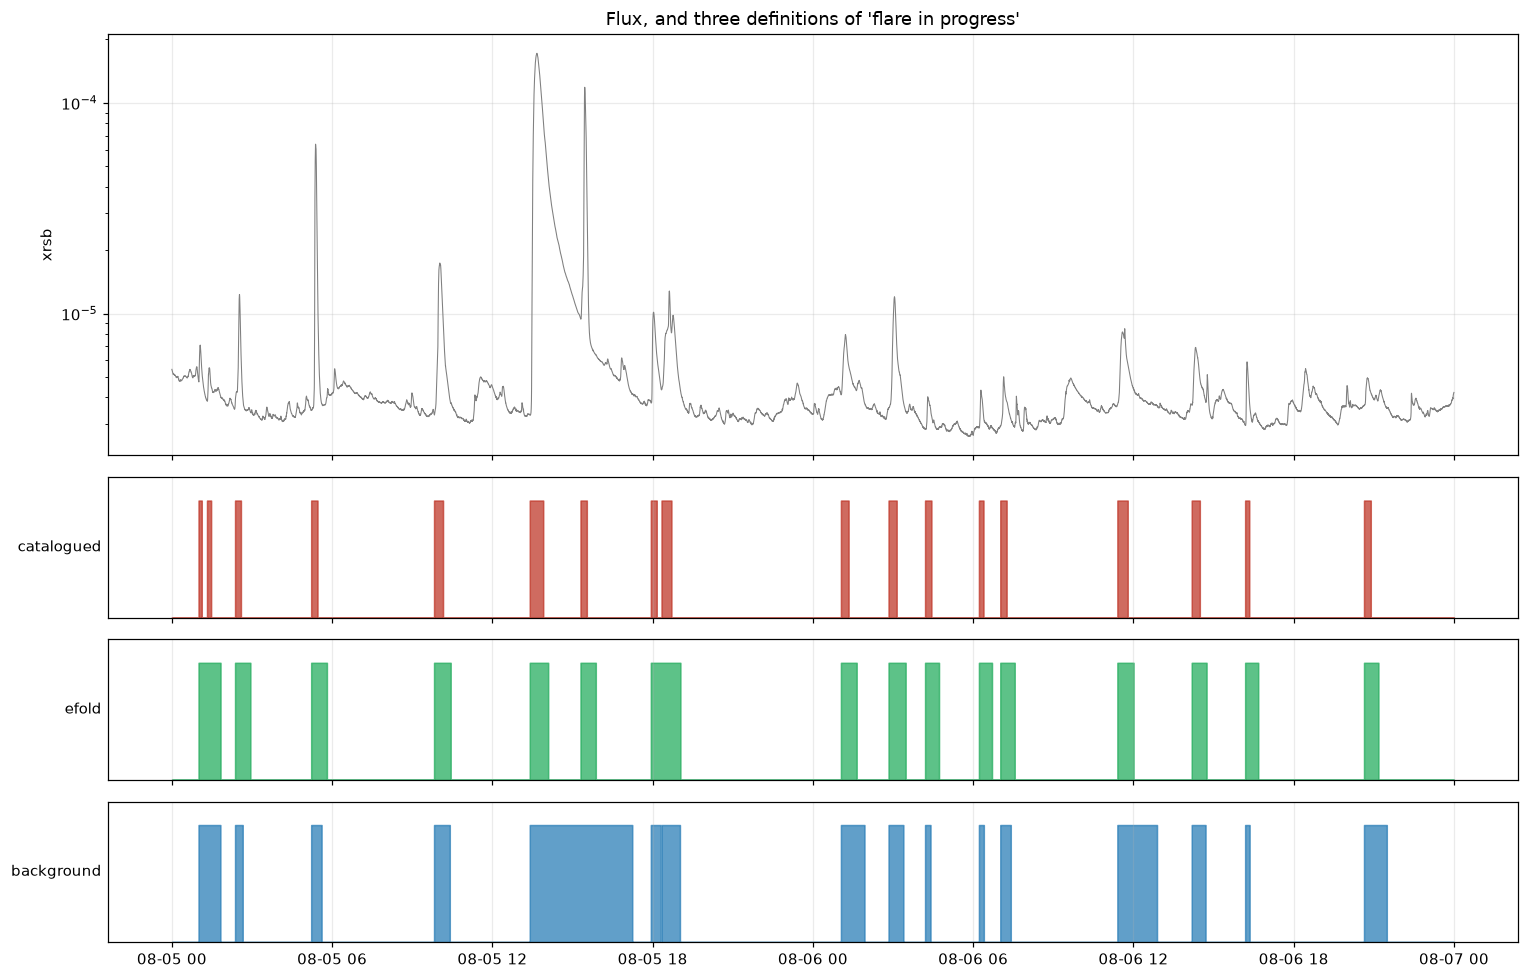

In [7]:
# See them. One day, three definitions stacked over the flux.
day = slice("2024-08-05", "2024-08-06")
sub = m.loc[day]
pos = m.index.get_indexer(sub.index)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1, 1, 1]})

axes[0].plot(sub.index, sub["xrsb_clean"], lw=0.7, color="gray")
axes[0].set_yscale("log")
axes[0].set_ylabel("xrsb")
axes[0].set_title("Flux, and three definitions of 'flare in progress'")

for ax, (name, col) in zip(axes[1:], [("catalogued", SOFT), ("efold", GOOD), ("background", ACC)]):
    yy = schemes[name][0][pos]
    ax.fill_between(sub.index, 0, yy, step="mid", color=col, alpha=0.75)
    ax.set_ylim(0, 1.2)
    ax.set_yticks([])
    ax.set_ylabel(name, rotation=0, ha="right", va="center")

plt.tight_layout()
plt.show()

**What to look for.** The `catalogued` band should end while the flux is
still visibly falling. The `background` band should merge neighbouring flares
into long continuous blocks — that is the failure mode that makes it unusable
during solar maximum. The `efold` band should track the actual decay without
running into the next event.

## 4. The early-warning label

This is the one that delivers your pitch. At time *t*:

> Will an **M-class or larger** flare reach its peak within the next H minutes?

`HORIZON_MIN = 10` is set from physics: median rise is 8 minutes, so a 10-minute
horizon is reachable. Fifteen would not be.

The diagnostic below matters more than the label. It splits positive times into
those where a flare had **already started** (the model can see a rise — this is
nowcasting, and X-rays can do it) and those where **nothing has begun yet**
(the model would have to predict from quiet Sun — that needs magnetograms, and
X-rays cannot).

That split is the honest boundary of what this project can promise.

In [8]:
def warning_label(index, fl, horizon_min=HORIZON_MIN, min_cls=2):
    y = np.zeros(len(index), dtype=np.int8)
    started = np.zeros(len(index), dtype=np.int8)
    idx = index.values
    H = pd.Timedelta(minutes=horizon_min)

    for _, f in fl.iterrows():
        if f["cls_id"] < min_cls:
            continue
        peak, start = f["event_peaktime"], f["event_starttime"]
        sel = (idx > np.datetime64(peak - H)) & (idx <= np.datetime64(peak))
        y[sel] = 1
        started[sel & (idx >= np.datetime64(start))] = 1
    return y, started


y_warn, warn_started = warning_label(m.index, fl)

n_pos = y_warn.sum()
n_seen = warn_started.sum()
print(f"positive warning samples : {n_pos:,} ({100*y_warn.mean():.2f}% of the week)")
print(f"  flare already underway : {n_seen:,} ({100*n_seen/max(n_pos,1):.1f}%)  <- nowcastable from X-rays")
print(f"  nothing started yet    : {n_pos-n_seen:,} ({100*(n_pos-n_seen)/max(n_pos,1):.1f}%)  <- needs magnetograms")
print()
for h in [3, 5, 10, 15, 20]:
    yy, ss = warning_label(m.index, fl, horizon_min=h)
    frac = 100 * ss.sum() / max(yy.sum(), 1)
    print(f"  horizon {h:>2} min -> {100*yy.mean():5.2f}% positive, {frac:5.1f}% already underway")

positive warning samples : 3,102 (5.13% of the week)
  flare already underway : 2,566 (82.7%)  <- nowcastable from X-rays
  nothing started yet    : 536 (17.3%)  <- needs magnetograms

  horizon  3 min ->  1.55% positive, 100.0% already underway
  horizon  5 min ->  2.58% positive,  98.3% already underway
  horizon 10 min ->  5.13% positive,  82.7% already underway
  horizon 15 min ->  7.66% positive,  66.2% already underway
  horizon 20 min -> 10.16% positive,  54.0% already underway


**Read the horizon sweep.** As the horizon grows, the "already underway"
fraction falls — you are asking further ahead than the flare has existed. Where
that number drops sharply is the point past which soft X-rays stop being
sufficient, and it is a defensible place to set your claim.

## 5. Cut the windows

Each sample is a `WINDOW_MIN` slice of history, and its label describes the
**last** timestamp in that slice — the "now" moment. Labelling by window end,
not window centre, is what keeps the setup causal.

In [9]:
LABEL_SCHEME = "efold"          # <- the decision; change and re-run to compare

y_prog, y_cls = schemes[LABEL_SCHEME]

W = int(WINDOW_MIN * 60 / cad_s)
S = max(1, int(STRIDE_S / cad_s))
print(f"window {W} samples = {WINDOW_MIN} min   |   stride {S} samples = {STRIDE_S}s")

feat = m[FEATURES].astype(np.float32).values
sw = sliding_window_view(feat, W, axis=0)          # (N-W+1, F, W)
sw = np.ascontiguousarray(sw.transpose(0, 2, 1))   # (N-W+1, W, F)

X       = sw[::S].copy()
t_end   = m.index[W-1:][::S]                       # timestamp of each window's LAST sample
yp      = y_prog[W-1:][::S]
yc      = y_cls[W-1:][::S]
yw      = y_warn[W-1:][::S]
ws      = warn_started[W-1:][::S]

# a window is usable only if every sample in it is valid AND no NaNs slipped in
vmask   = sliding_window_view(m["valid"].values, W)[::S].all(axis=1)
finite  = np.isfinite(X).all(axis=(1, 2))
keep    = vmask & finite

print(f"windows built   : {len(X):,}")
print(f"  dropped, invalid data : {(~vmask).sum():,}")
print(f"  dropped, non-finite   : {(vmask & ~finite).sum():,}")
print(f"  kept                  : {keep.sum():,}")
print(f"X shape (pre-filter): {X.shape}  (windows, timesteps, features)")
print(f"memory : {X.nbytes/1e6:.1f} MB")

window 180 samples = 30 min   |   stride 6 samples = 60s
windows built   : 10,051
  dropped, invalid data : 92
  dropped, non-finite   : 0
  kept                  : 9,959
X shape (pre-filter): (10051, 180, 6)  (windows, timesteps, features)
memory : 43.4 MB


In [10]:
X, t_end, yp, yc, yw, ws = X[keep], t_end[keep], yp[keep], yc[keep], yw[keep], ws[keep]

print("CLASS BALANCE")
print(f"  flare in progress : {yp.sum():,} / {len(yp):,}  ({100*yp.mean():.1f}%)")
print(f"  warning positive  : {yw.sum():,} / {len(yw):,}  ({100*yw.mean():.2f}%)")
print()
print("  by flare class:")
for name, cid in [("none", 0), ("C", 1), ("M", 2), ("X", 3)]:
    n = (yc == cid).sum()
    print(f"    {name:>4}: {n:>6,}  ({100*n/len(yc):5.2f}%)")
print()
imb = (yw == 0).sum() / max((yw == 1).sum(), 1)
print(f"Warning-label imbalance: {imb:.0f} negatives per positive.")
print("This is why accuracy is useless here and TSS/HSS are the metrics.")

CLASS BALANCE
  flare in progress : 2,927 / 9,959  (29.4%)
  warning positive  : 493 / 9,959  (4.95%)

  by flare class:
    none:  7,032  (70.61%)
       C:  1,150  (11.55%)
       M:  1,702  (17.09%)
       X:     75  ( 0.75%)

Warning-label imbalance: 19 negatives per positive.
This is why accuracy is useless here and TSS/HSS are the metrics.


## 6. Save

Windows are 3-D, so Parquet is out — `npz` handles it and compresses well.
Timestamps are saved alongside because **Step 7 splits chronologically**, and
that is impossible without knowing when each window ends.

In [11]:
out = DATA / "windows.npz"
np.savez_compressed(
    out,
    X=X,
    t_end=t_end.values.astype("datetime64[ns]"),
    y_progress=yp,
    y_class=yc,
    y_warn=yw,
    warn_started=ws,
    features=np.array(FEATURES),
    meta=np.array([CADENCE, str(WINDOW_MIN), str(STRIDE_S),
                   str(HORIZON_MIN), LABEL_SCHEME, str(K_EFOLD)]),
)
print(f"Saved -> {out}  ({out.stat().st_size/1e6:.1f} MB)")

chk = np.load(out, allow_pickle=False)
print()
for k in chk.files:
    print(f"  {k:<13} {str(chk[k].shape):<20} {chk[k].dtype}")

Saved -> ..\data\windows.npz  (1.6 MB)

  X             (9959, 180, 6)       float32
  t_end         (9959,)              datetime64[ns]
  y_progress    (9959,)              int8
  y_class       (9959,)              int8
  y_warn        (9959,)              int8
  warn_started  (9959,)              int8
  features      (6,)                 <U11
  meta          (6,)                 <U5


## 7. What Step 6 produced, and what is left

| Array | Meaning |
|---|---|
| `X` | (windows, timesteps, features) — the model input |
| `t_end` | timestamp of each window's last sample |
| `y_progress` | is a flare in progress right now? |
| `y_class` | which class (0 none, 1 C, 2 M, 3 X) |
| `y_warn` | will an M+ flare peak within the horizon? |
| `warn_started` | for positives, had the flare already begun? |

**Decisions now recorded rather than assumed:** label scheme and `K`, input
cadence, window length, stride, and warning horizon. All six are in `meta`, so
a result can always be traced back to the configuration that produced it.

**Step 7** is the chronological split — train on earlier days, test on later
ones, never shuffled. With overlapping windows there is one more trap: a window
ending just before the split boundary shares most of its samples with one
starting just after. That needs a gap between train and test, or the test set is
partly memorised. Next notebook.